Name: Emily Savoie

Labpartner(s): Maya Maes-Johnson

In [1]:
#import statements go here
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

**For today's lab you need to install the package cartopy**

In [ ]:
# you can install packages here in a notebook with pip or conda, 
# or in the anaconda navigator in the environments tab (reccommended)
# pip install cartopy
# conda install cartopy

In [2]:
# I had an old version of cartopy so I had to upgrade:
#%pip install --upgrade cartopy

In [2]:
import cartopy.crs as ccrs   #import map styles/types
import cartopy.feature as cfeature  # features such as the ocean, coastlines rivers, etc

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Class 6.2

Today we will finish fiunction sharing and do more plotting

# Warmups 6.2

**W.1** Write some code that generates 15 random integers from 1-100. If the integers are divisible by 2 assign them to list "x" if they are divisible by three, assign them to list "y", if they are neither assign them to list "z". 

In [3]:
nums = np.random.randint(1,101,15)
nums

array([20, 86,  5, 25, 36,  3, 85, 32, 52, 34, 79, 84, 70, 73, 90])

In [24]:
x = []
y = []
z = []

for num in nums:
    if num % 2 == 0:
        x.append(int(num))
    elif num % 3 == 0:
        y.append(int(num))
    else:
        z.append(int(num))

print(x)
print(y)
print(z)

[20, 86, 36, 32, 52, 34, 84, 70, 90]
[3]
[5, 25, 85, 79, 73]


# Lecture 6.2

### Agenda:

- Show us your functions
- Questions
- Cartopy


### Show us your functions (from Lab 5.2) - continued

### Questions

### Cartopy

Let's take the data we used last time and make the plot publication ready

There are a number of differnt map projections available in Cartopy.  
https://cartopy.readthedocs.io/stable/reference/projections.html
Robinson is often used for global maps

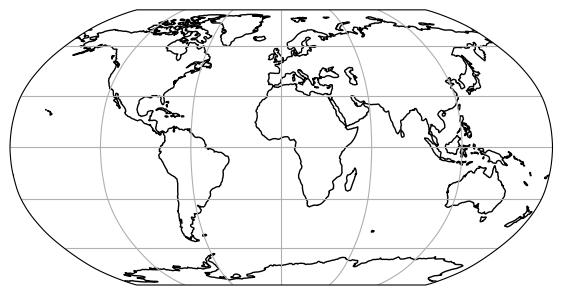

In [6]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
# Projection is map style to be used
ax = plt.axes(projection=ccrs.Robinson())
ax.coastlines(resolution='110m')
ax.gridlines()

When we are plotting ocean data, we like to make the Pacific contiguous, let's rotate

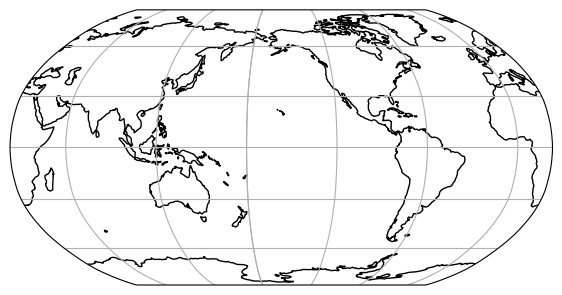

In [7]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = 203)) # this rotates the map to 203 degrees East
ax.coastlines(resolution='110m')
ax.gridlines()

Or we can rotate it so that it cuts through Indonesia (not good for mangrove or coral work)

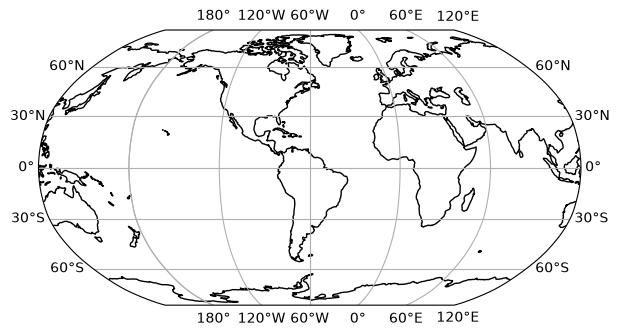

In [8]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = -60))
# -60 (60 W) is the same as 300 E (360 degrees in total 360-60W = 300E)
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True) # let's add some labels

Let's try some different map projections

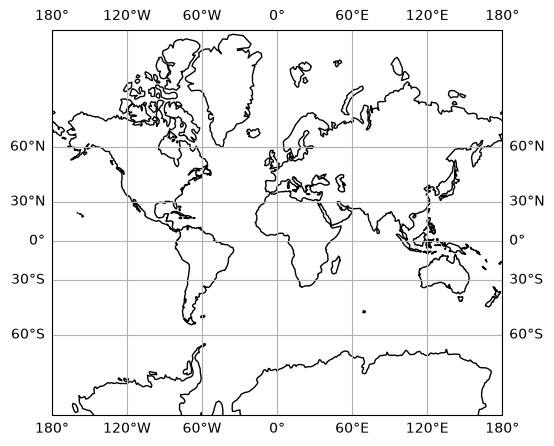

In [9]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Mercator()) # different map projection
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)

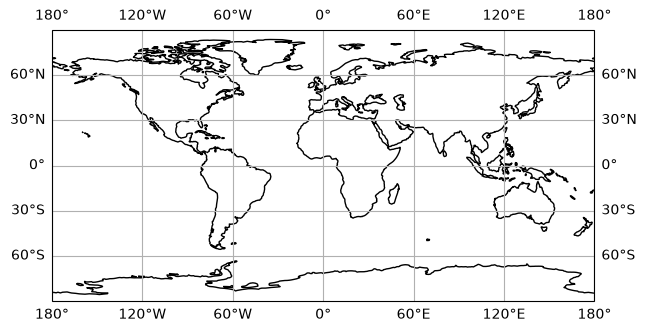

In [29]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)


How do I zoom in?

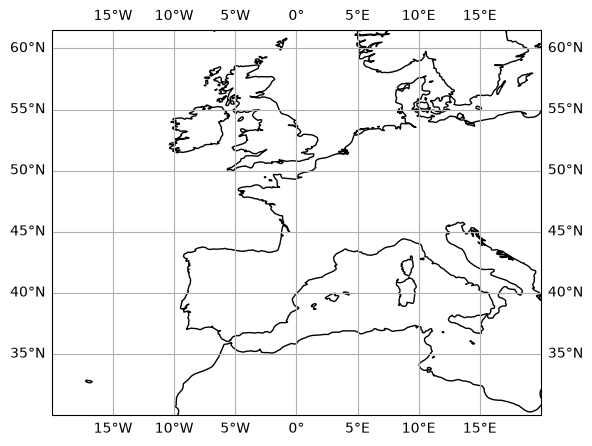

In [10]:
# let's zoom in to S Asia
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-20, 20, 30, 60]) # set the limits of the plot
# more zoomed in means need better resolution
ax.coastlines(resolution='50m')
ax.gridlines(draw_labels=True)


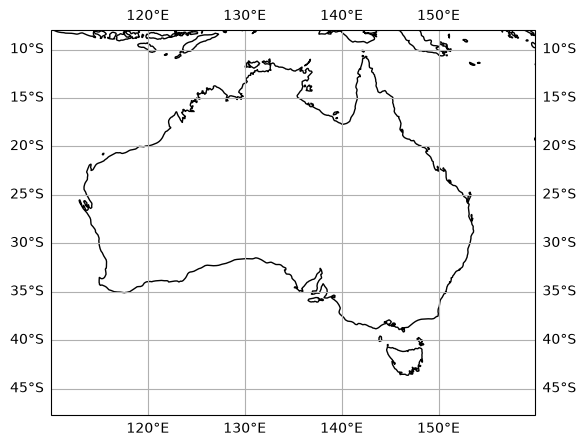

In [11]:
# make a plot of Australia

plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([110, 160, -8, -45]) # set the limits of the plot
ax.coastlines(resolution='50m')
ax.gridlines(draw_labels=True)

#### Moving back to the Gulf of Mexico, we want to set the lat and lon range to match our HYCOM data. How do we find this?

In [12]:
#insert path or url to file here
# download from the internet:
link = "https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_00_2d.nc"

In [14]:
gom_data = xr.open_dataset(link, decode_times=False)

In [15]:
gom_data

<xarray.Dataset> Size: 5MB
Dimensions:                (MT: 1, Latitude: 385, Longitude: 525)
Coordinates:
  * MT                     (MT) float64 8B 4.566e+04
    Date                   (MT) float64 8B ...
  * Latitude               (Latitude) float32 2kB 18.09 18.13 ... 31.93 31.96
  * Longitude              (Longitude) float32 2kB -98.0 -97.96 ... -77.04
Data variables:
    surface_e_stress       (MT, Latitude, Longitude) float32 808kB ...
    surface_n_stress       (MT, Latitude, Longitude) float32 808kB ...
    ssh                    (MT, Latitude, Longitude) float32 808kB ...
    u_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    v_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    mixed_layer_thickness  (MT, Latitude, Longitude) float32 808kB ...
Attributes:
    Conventions:                     CF-1.6
    title:                           HYCOM
    source:                          HYCOM archive file
    experiment:                      01.4
    history:                         archv2ncdf2d
    comment:                         p-grid
    DODS_EXTRA.Unlimited_Dimension:  MT

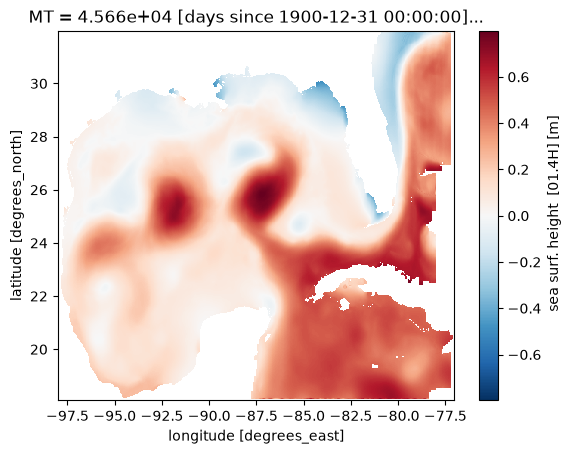

In [46]:
# let's remember what our data looked like, pick a variable to plot

gom_data.ssh.plot()

I'm going to get the max and min of the lat and lon to help me plot the data

In [16]:
lat_min = gom_data.Latitude.min()
print(lat_min)

<xarray.DataArray 'Latitude' ()> Size: 4B
array(18.091648, dtype=float32)
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y


In [17]:
lat_max = gom_data.Latitude.max()
print(lat_max)

<xarray.DataArray 'Latitude' ()> Size: 4B
array(31.960648, dtype=float32)
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y


In [18]:
lon_min = gom_data.Longitude.min()
print(lon_min)

<xarray.DataArray 'Longitude' ()> Size: 4B
array(-98., dtype=float32)
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X


In [19]:
lon_max = gom_data.Longitude.max()
print(lon_max)

<xarray.DataArray 'Longitude' ()> Size: 4B
array(-77.03998, dtype=float32)
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X


Now I can use them below

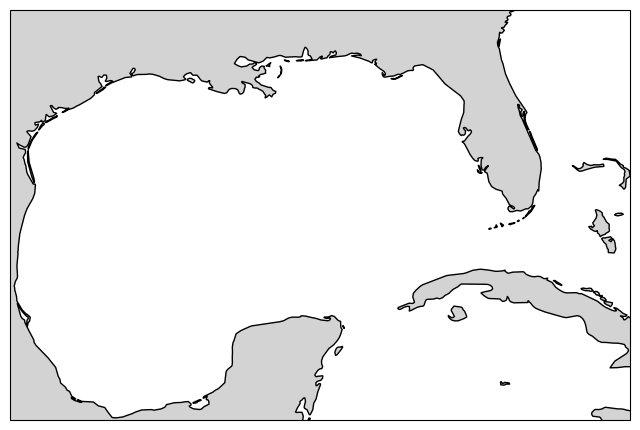

In [20]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='lightgrey')
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

#### Let's make the land color a bit lighter gray

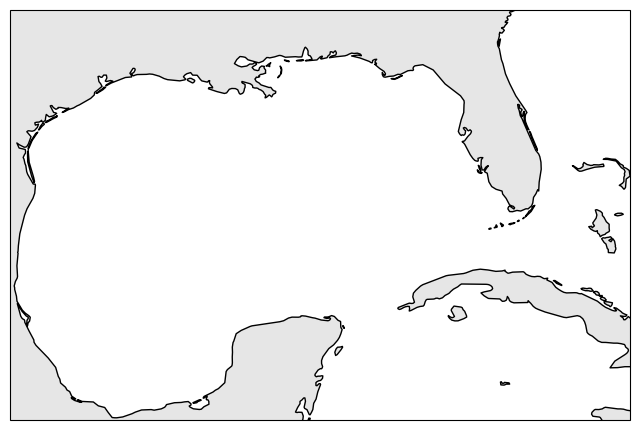

In [55]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9') # 0 is black and 1 is white
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

#### Now let's add some data

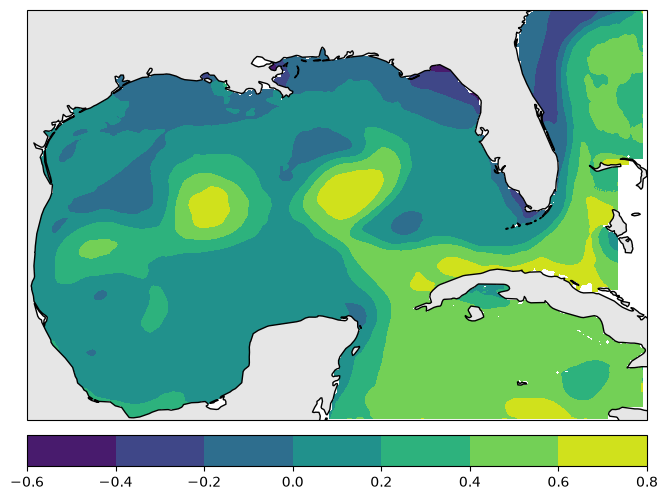

In [64]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 

# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
# Get rid of time dimension so that var is 2D not 3D
var = gom_data.ssh[0]

# Contours the data on tho the map projection
p = ax.contourf(x, y, var, transform=ccrs.PlateCarree()) # projection is needed in every plot call

# Creates colorbar based on the contour. This allows us to get a quick look at our data range 
# before we start formatting the figure 
cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)


#### Try taking out the options for the colorbar, what happens? What does "pad" do?

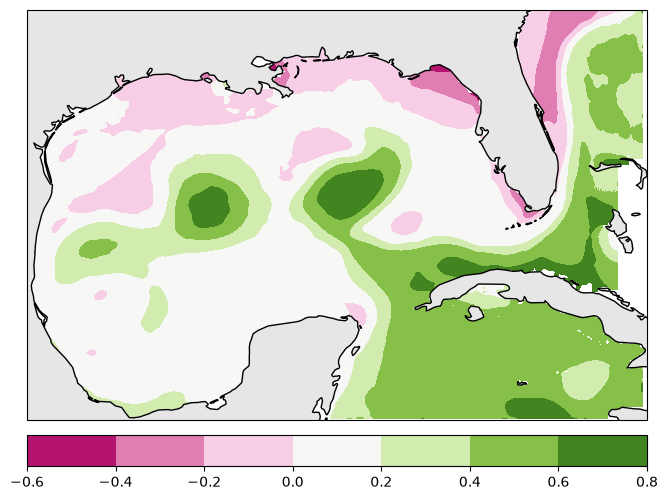

In [72]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 

# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
# Get rid of time dimension so that var is 2D not 3D
var = gom_data.ssh[0]

# Contours the data on tho the map projection
p = ax.contourf(x, y, var, transform=ccrs.PlateCarree(), cmap = 'PiYG') # projection is needed in every plot call

# Creates colorbar based on the contour. This allows us to get a quick look at our data range 
# before we start formatting the figure 
cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)

# pad adjust the space between th colorbar and the plot
# orientation is orientation of colorbar on plot


#### What is the range of our data?

In [68]:
print(var.max())

<xarray.DataArray 'ssh' ()> Size: 4B
array(0.7986358, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]


In [69]:
print(var.min())

<xarray.DataArray 'ssh' ()> Size: 4B
array(-0.504511, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]


#### Let's set the countour levels to match our data range. I'm also going to change the colormap
See https://matplotlib.org/stable/users/explain/colors/colormaps.html
Note you can reverse any colormap by appending '_r' to the name

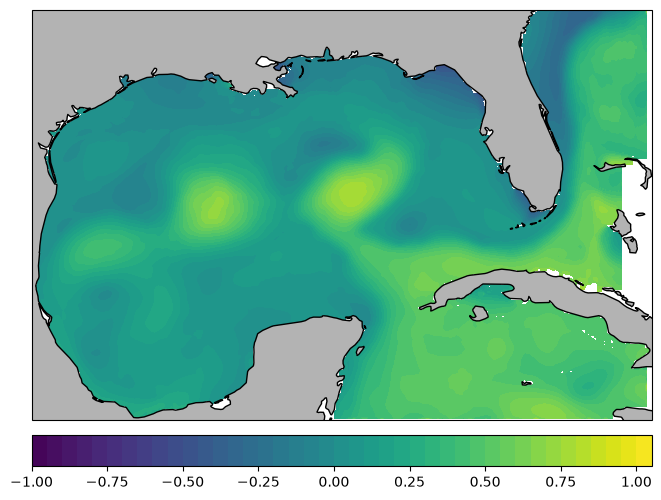

In [90]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0]

# let's fill in the range here:
step = np.arange(-1,1.1,0.05)
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'viridis', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)


#### Okay, now let's add some labels

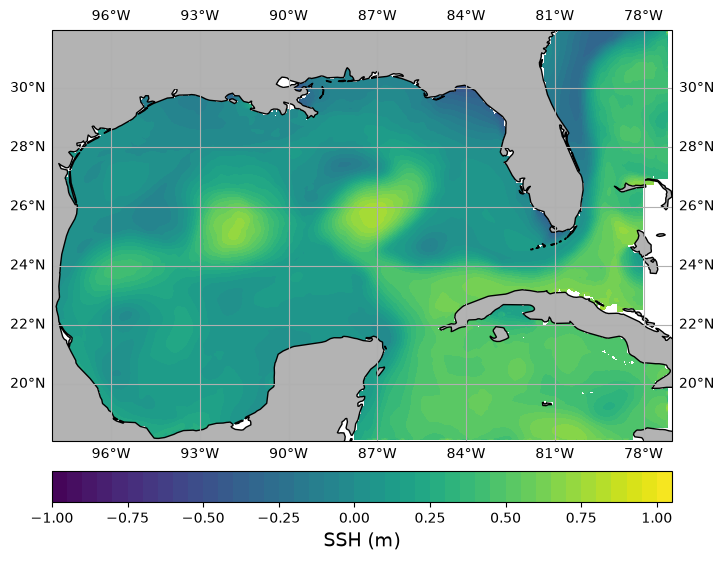

In [92]:
# copy in previous code here
# I'm also going to cut out the white bits at right by adjusting lon_max
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0]

# let's fill in the range here:
step = np.arange(-1,1.1,0.05)
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'viridis', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.04)


cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True)


#### These labels are too small for what I want. I need them to be much bigger.

In [102]:
#Note we can easily make the lat/lon and colorbar font size bigger by adjusting the matplotlib parameters, 
# which I introduced last time
import matplotlib as mpl
mpl.rcParams['font.size'] = 14

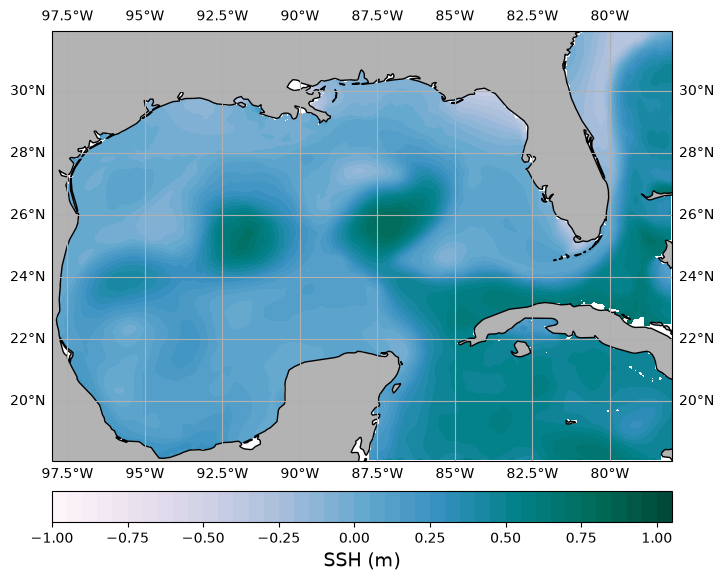

In [21]:
#exact same code as before
# copy in previous code here
# I'm also going to cut out the white bits at right by adjusting lon_max
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, -78, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0]

# let's fill in the range here:
step = np.arange(-1,1.1,0.05)
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'PuBuGn', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.04)


cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True)

#### Not bad

## Lab 6.2

**E.0** Finish Lab 6.1 if you haven't already.

**E.1** Complete Introduction to Data Visualization with Matplotlib Chapters 3-4. Let me know if this feels like a good pace

**E.2** Make notes for yourself on progamming tecniques and commands you learned in the lecture and datacamp chapter above, including examples, comments and explainitory text. You can do this here or in a separate notebook that you link to here. Basically, you are making a cheat sheet for yourself.

Notes for chapters 3-4 were included on the other lab with chapters 1-2.

**E.3** Make a plot of a different variable for the HYCOM data. Play around with colormaps and contourlines to make it your own. Post your plot on the class slack #programming channel

In [25]:
var = gom_data.mixed_layer_thickness[0]
print(var.max())
print(var.min())

<xarray.DataArray 'mixed_layer_thickness' ()> Size: 4B
array(146.06506, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  ocean_mixed_layer_thickness
    units:          m
    valid_range:    [  0.5431862 146.06506  ]
    long_name:      mix.layr.thickness [01.4H]
    _ChunkSizes:    [  1 385 525]
<xarray.DataArray 'mixed_layer_thickness' ()> Size: 4B
array(0.5431862, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  ocean_mixed_layer_thickness
    units:          m
    valid_range:    [  0.5431862 146.06506  ]
    long_name:      mix.layr.thickness [01.4H]
    _ChunkSizes:    [  1 385 525]


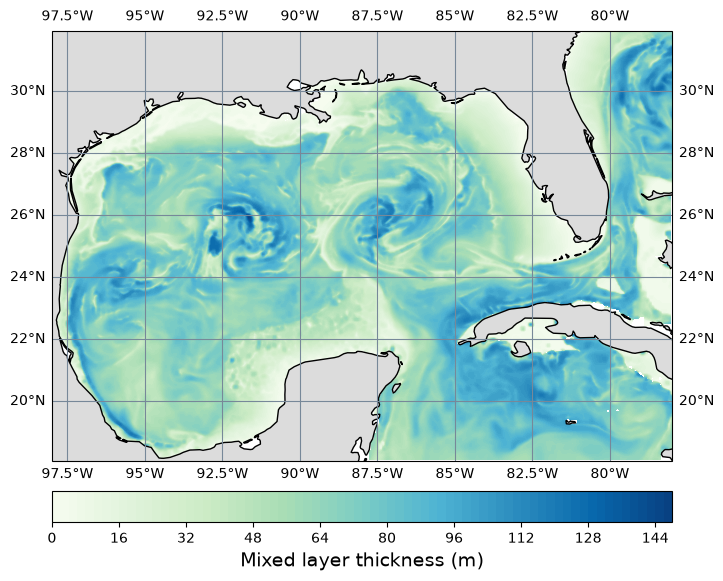

In [44]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, -78, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='gainsboro')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.mixed_layer_thickness[0]

step = np.arange(0,149,2)
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'GnBu',
               levels = step)

cbar = plt.colorbar(p, orientation='horizontal', pad=0.04)


cbar.set_label("Mixed layer thickness" +' (m)', size = 14)

ax.gridlines(draw_labels=True, color = 'lightslategray')

fig.savefig('mixed_layer_gom.png', dpi = 300)

### This week's project:

#### Note you might want to restart your kernel at this point to dump all the hycom data from memory. Just reload the packages you need

**E.4** Download some data from the ISIMIP data archive (https://data.isimip.org/) and plot it using cartopy. ISIMIP provides bias-corrected daata for past and future climate simulations used for impacts studies world wide. Let's start with some maximum atmospheric surface temperature data in the historical period (1850-2014 for CMIP6). We want climate forcing data for ISIMIP3b, which are the lastest (CMIP6) climate projections. 

* https://data.isimip.org/search/tree/ISIMIP3b/InputData/climate/
* Click atmopsheric forcing
* Click GFDL... This is one of NOAA-GFDL's climate models (ESM4)
* Click historical

All of the variable names are in CMIP lingo. Sadly, there is no easy cheat sheet. But you want tas, which is "temperature of air at surface". Let's use the tasmax, the maximum daily surface air temperature
* Click tasmax
* Click files to see all the available files.
  
Here you have a choice, you can download an etire file (note the size) or you can use the "configure download" button, which has subsetting by space or country, as well as time opitons. You can click on a file name to see more info.
* Click on "download file" for the 1851-1860 file. Just grab the whole file, it will take a minute to download.
* Load up the data into xarray and plot the maximum of this dataset (so max over the decade for each gridcell. You just use a max function for this, no loops needed).
* Plot using cartopy to make it pretty. Put some sensible lables on it, etc. Maybe add some country boundaries.

In [14]:
file_path ='gfdl-esm4_r1i1p1f1_w5e5_historical_tasmax_global_daily_1851_1860.nc'
isimip1850_data = xr.open_dataset(file_path, decode_times = False)
isimip1850_data

<xarray.Dataset> Size: 4GB
Dimensions:  (time: 3653, lat: 360, lon: 720)
Coordinates:
  * time     (time) float64 29kB 0.0 1.0 2.0 ... 3.65e+03 3.651e+03 3.652e+03
  * lat      (lat) float64 3kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Data variables:
    tasmax   (time, lat, lon) float32 4GB ...
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [51]:
# Get max for data
isimip1850_max = isimip1850_data.max(dim = 'time')
# Convert from Kelvin to Celsius
isimip1850_max['tasmax'] = isimip1850_max['tasmax'] - 273.15
isimip1850_max

<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 360, lon: 720)
Coordinates:
  * lat      (lat) float64 3kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Data variables:
    tasmax   (lat, lon) float32 1MB 1.739 1.757 1.73 ... -14.91 -14.87 -14.88
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [56]:
var = isimip1850_max.tasmax
# Get min and max values for variable to set appropriate range
print(var.max())
print(var.min())

<xarray.DataArray 'tasmax' ()> Size: 4B
array(52.400116, dtype=float32)
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    units:          K
<xarray.DataArray 'tasmax' ()> Size: 4B
array(-21.383423, dtype=float32)
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    units:          K


In [52]:
# Save max values to netcdf file
isimip1850_max.to_netcdf('isimip1850_max.nc')

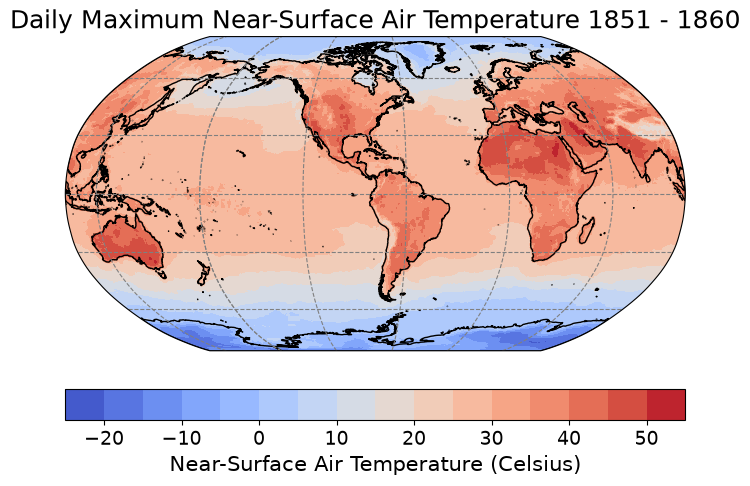

In [103]:
# Plot using Robinson projection 
fig, ax = plt.subplots(figsize = (8, 10), 
                       subplot_kw = dict(projection = ccrs.Robinson(central_longitude = -78)))

ax.set_title('Daily Maximum Near-Surface Air Temperature 1851 - 1860',
            size = 18)

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                        edgecolor = 'black',
                                        facecolor = 'none')

ax.add_feature(land_50m)

# Set x, y, and var
x = isimip1850_max.lon
y = isimip1850_max.lat
var = isimip1850_max.tasmax

step = np.arange(-25, 60, 5)
# Have to indicate what projection the data is in so that it can be put onto Robinson
p = ax.contourf(x, y, var, transform = ccrs.PlateCarree(),
               cmap = 'coolwarm', levels = step)

cbar = plt.colorbar(p, orientation = 'horizontal', pad = 0.05)
cbar.set_label('Near-Surface Air Temperature (Celsius)',
              size = 15)

ax.gridlines(color = 'grey', linestyle = '--')

**E.5** Now make a second plot using ISIMP data for a future climate projection. Following the same steps as above, get the GFDL tasmax data for the future climate scenario SSP3-7.0 (higher emissions scenario) for 2051-2060. Again, calculate the maximum at each gridpoint for this data set. This is the future maximum daily temperature for that decade. Make your plot nice.

In [60]:
file_path ='gfdl-esm4_r1i1p1f1_w5e5_ssp370_tasmax_global_daily_2051_2060.nc'
isimip2050_data = xr.open_dataset(file_path, decode_times = False)
isimip2050_data

<xarray.Dataset> Size: 4GB
Dimensions:  (time: 3653, lat: 360, lon: 720)
Coordinates:
  * time     (time) float64 29kB 0.0 1.0 2.0 ... 3.65e+03 3.651e+03 3.652e+03
  * lat      (lat) float64 3kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Data variables:
    tasmax   (time, lat, lon) float32 4GB ...
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [61]:
# Get max for data
isimip2050_max = isimip2050_data.max(dim = 'time')
# Convert from Kelvin to Celsius
isimip2050_max['tasmax'] = isimip2050_max['tasmax'] - 273.15
isimip2050_max

<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 360, lon: 720)
Coordinates:
  * lat      (lat) float64 3kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Data variables:
    tasmax   (lat, lon) float32 1MB 2.195 2.193 2.206 ... -18.15 -17.86 -18.14
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [62]:
# Save max values to netcdf file
isimip2050_max.to_netcdf('isimip2050_max.nc')

In [63]:
# Get min and max of variable to make sure range is ok
var = isimip2050_max.tasmax
print(var.min())
print(var.max())

<xarray.DataArray 'tasmax' ()> Size: 4B
array(-19.481018, dtype=float32)
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    units:          K
<xarray.DataArray 'tasmax' ()> Size: 4B
array(55.42627, dtype=float32)
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    units:          K


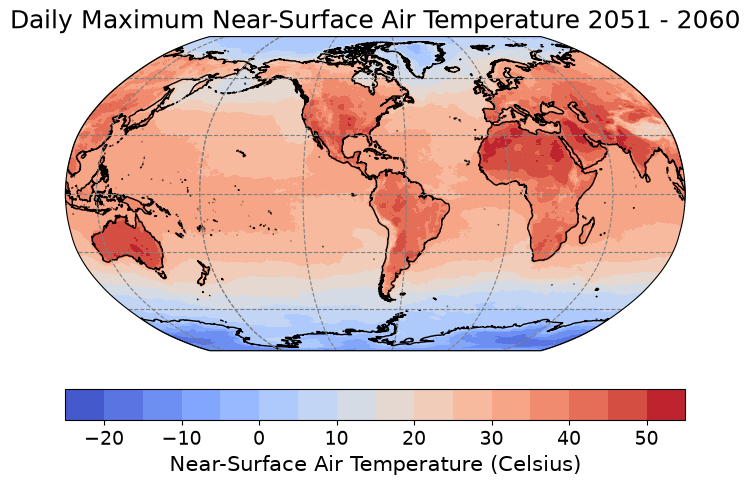

In [104]:
# plot using Robinson projection 
fig, ax = plt.subplots(figsize = (8, 10), 
                       # Central longitude moved to minimize breaking of oceans
                       subplot_kw = dict(projection = ccrs.Robinson(central_longitude = -78)))

ax.set_title('Daily Maximum Near-Surface Air Temperature 2051 - 2060',
            size = 18)

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                        edgecolor = 'black',
                                        facecolor = 'none')

ax.add_feature(land_50m)

# Set x, y, and var
x = isimip2050_max.lon
y = isimip2050_max.lat
var = isimip2050_max.tasmax

step = np.arange(-25, 60, 5)
# projection indicates what the data is in so that it can be put onto Robinson
p = ax.contourf(x, y, var, transform = ccrs.PlateCarree(),
               cmap = 'coolwarm', levels = step)

cbar = plt.colorbar(p, orientation = 'horizontal', pad = 0.05)
cbar.set_label('Near-Surface Air Temperature (Celsius)',
              size = 15)

ax.gridlines(color = 'grey', linestyle = '--')

**E.6** Now plot the anomaly between the two, 2050's - 1850's. Use a diverging colormap (light in the middle), centered on zero. What is the outlook for your country of orgin? Answer in full sentances with specific numbers.

In [72]:
# Get the difference between past records and future projections
tasmax_diff = isimip2050_max.copy()
tasmax_diff['tasmax'] = tasmax_diff['tasmax'] - isimip1850_max['tasmax']
tasmax_diff

<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 360, lon: 720)
Coordinates:
  * lat      (lat) float64 3kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Data variables:
    tasmax   (lat, lon) float32 1MB 0.4561 0.4357 0.4763 ... -2.983 -3.259
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [73]:
# Save to netcdf
tasmax_diff.to_netcdf('tasmax_diff.nc')

In [75]:
# Get min and max values for range
var = tasmax_diff.tasmax
print(var.min())
print(var.max())

<xarray.DataArray 'tasmax' ()> Size: 4B
array(-8.306732, dtype=float32)
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    units:          K
<xarray.DataArray 'tasmax' ()> Size: 4B
array(10.86084, dtype=float32)
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    units:          K


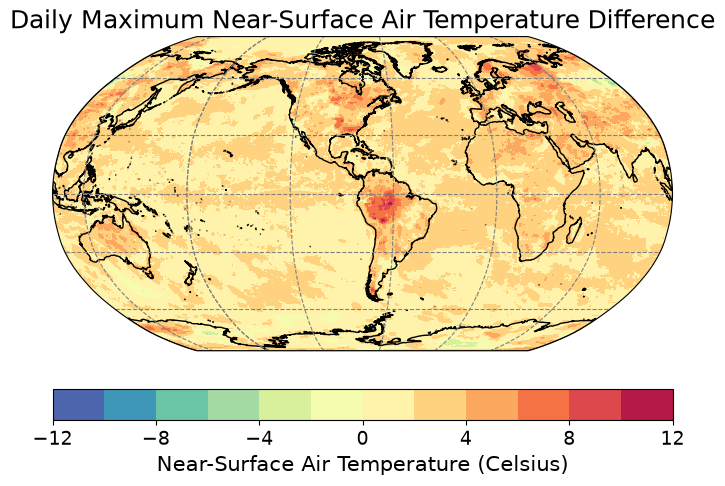

In [105]:
# plot using Robinson projection 
fig, ax = plt.subplots(figsize = (8, 10), 
                       # Central longitude moved to minimize breaking of oceans
                       subplot_kw = dict(projection = ccrs.Robinson(central_longitude = -78)))

ax.set_title('Daily Maximum Near-Surface Air Temperature Difference',
            size = 18)

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                        edgecolor = 'black',
                                        facecolor = 'none')

ax.add_feature(land_50m)

# Set x, y, and var
x = tasmax_diff.lon
y = tasmax_diff.lat
var = tasmax_diff.tasmax

step = np.arange(-12, 14, 2)
# projection indicates what the data is in so that it can be put onto Robinson
p = ax.contourf(x, y, var, transform = ccrs.PlateCarree(),
               cmap = 'Spectral_r', levels = step)

cbar = plt.colorbar(p, orientation = 'horizontal', pad = 0.05)
cbar.set_label('Near-Surface Air Temperature (Celsius)',
              size = 15)

ax.gridlines(color = 'grey', linestyle = '--')

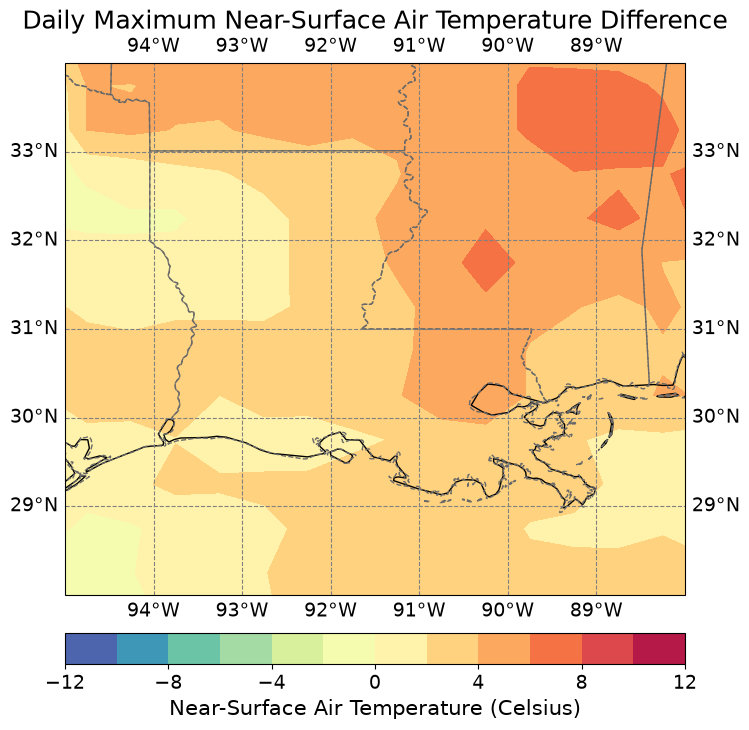

In [ ]:
# Plot just of Louisiana for temperature difference
fig, ax = plt.subplots(figsize = (8, 10), 
                       # Central longitude moved to minimize breaking of oceans
                       subplot_kw = dict(projection = ccrs.PlateCarree()))
# Set coordinates to be zoomed on Louisiana
ax.set_extent([-95, -88, 28, 34])

ax.set_title('Daily Maximum Near-Surface Air Temperature Difference',
            size = 18)

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                        edgecolor = 'black',
                                        facecolor = 'none')

ax.add_feature(land_50m)
# Add state borders
ax.add_feature(cfeature.STATES, edgecolor = 'dimgray', linestyle = '--')

# Set x, y, and var
x = tasmax_diff.lon
y = tasmax_diff.lat
var = tasmax_diff.tasmax

step = np.arange(-12, 14, 2)
# projection indicates what the data is in so that it can be put onto Robinson
p = ax.contourf(x, y, var, transform = ccrs.PlateCarree(),
               cmap = 'Spectral_r', levels = step)

cbar = plt.colorbar(p, orientation = 'horizontal', pad = 0.05)
cbar.set_label('Near-Surface Air Temperature (Celsius)',
              size = 15)

ax.gridlines(draw_labels = True, color = 'grey', linestyle = '--')

Louisiana shows a projection of warming temperature throughout the whole state, with some areas predicting between 0-2 degrees increase and others between 4-6 degrees. Most of the state has an outlook of a 2-4 degrees increase.

**E.7** How could you potentially use this kind of data (future climate projections) in your research? Do some brainstorming. Write down your thoughts here.

Future climate projections along the coast of Louisiana could be used in my coastal ecology research. This can help determine the types of physiological experiments that would provide useful information for potential impacts to the community composition in the estuaries. Having estimates for potential climate change can help with understanding the potential community shifts and the impacts those shifts could have on the overall health and function of the ecosystem.